MCA572– Neural Networks and Deep Learning

V MCA
23-09-2024

Regular lab Question – I

Jethro Jarvis Roy Jyrwa

5 MCA A | 2447122

You have been tasked with building simple neural networks to simulate the behavior of logicgates using a Single Layer Perceptron. This task will involve constructing, training, and testing perceptrons for the following gates: AND, OR, AND-NOT and XOR.


1. AND Gate Classification

• Scenario:
You are tasked with building a simple neural network to simulate an AND gate using a Single Layer Perceptron. The AND gate outputs 1 only if both inputs are 1; otherwise, it outputs 0.

• Lab Task: Implement a Single Layer Perceptron using Python in Google Colab to classify the output of an AND gate given two binary inputs (0 or 1). Follow these steps:

• Create a dataset representing the truth table of the AND gate.

In [3]:
# === SETUP ===
import numpy as np
import matplotlib.pyplot as plt

# Dataset for AND gate
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([0, 0, 0, 1])  # AND outputs

• Define the perceptron model with one neuron, including the activation function and weights initialization(Try both random weights and defined weights).

In [5]:
def step_function(x):
    return 1 if x >= 0 else 0

In [6]:
def predict(x, weights, bias):
    linear_output = np.dot(x, weights) + bias
    return step_function(linear_output)

In [19]:
def train_random_weights(X, y, learning_rate=0.1, epochs=20):
    # initialize weights and bias randomly
    weights = np.random.randn(X.shape[1])
    bias = np.random.randn(1)

    print(f"Initial weights: {weights}, bias: {bias}")

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}:")
        for xi, target in zip(X, y):
            pred = predict(xi, weights, bias)
            error = target - pred
            # update weights and bias
            weights += learning_rate * error * xi
            bias += learning_rate * error

            print(f" Input: {xi}, Target: {target}, Prediction: {pred}, Error: {error}")
            print(f" Updated weights: {weights}, bias: {bias}")
    return weights, bias

• Train the perceptron using a suitable learning algorithm (e.g., gradient descent).

In [20]:
weights, bias = train_random_weights(X, y, learning_rate=0.1, epochs=20)

Initial weights: [-0.73295005 -0.53810783], bias: [2.25596944]

Epoch 1:
 Input: [0 0], Target: 0, Prediction: 1, Error: -1
 Updated weights: [-0.73295005 -0.53810783], bias: [2.15596944]
 Input: [0 1], Target: 0, Prediction: 1, Error: -1
 Updated weights: [-0.73295005 -0.63810783], bias: [2.05596944]
 Input: [1 0], Target: 0, Prediction: 1, Error: -1
 Updated weights: [-0.83295005 -0.63810783], bias: [1.95596944]
 Input: [1 1], Target: 1, Prediction: 1, Error: 0
 Updated weights: [-0.83295005 -0.63810783], bias: [1.95596944]

Epoch 2:
 Input: [0 0], Target: 0, Prediction: 1, Error: -1
 Updated weights: [-0.83295005 -0.63810783], bias: [1.85596944]
 Input: [0 1], Target: 0, Prediction: 1, Error: -1
 Updated weights: [-0.83295005 -0.73810783], bias: [1.75596944]
 Input: [1 0], Target: 0, Prediction: 1, Error: -1
 Updated weights: [-0.93295005 -0.73810783], bias: [1.65596944]
 Input: [1 1], Target: 1, Prediction: 0, Error: 1
 Updated weights: [-0.83295005 -0.63810783], bias: [1.75596944]

• Test the model with all possible input combinations and display the results.

In [9]:
print("Testing AND Gate:")
for xi in X:
    print(f"Input: {xi}, Output: {predict(xi, weights, bias)}")


Testing AND Gate:
Input: [0 0], Output: 0
Input: [0 1], Output: 0
Input: [1 0], Output: 0
Input: [1 1], Output: 1


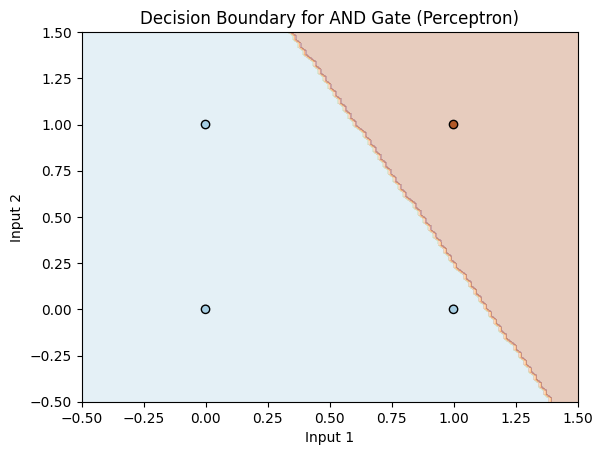

In [10]:
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# compute predictions for grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([predict(point, weights, bias) for point in grid_points])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap=plt.cm.Paired)
plt.title("Decision Boundary for AND Gate (Perceptron)")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()


In [15]:
def train_defined_weights(X, y, learning_rate=0.1, epochs=20):
    # initialize weights and bias defined
    weights = np.zeros(X.shape[1])
    bias = np.zeros(1)
    for _ in range(epochs):
        for xi, target in zip(X, y):
            pred = predict(xi, weights, bias)
            error = target - pred
            # update weights and bias
            weights += learning_rate * error * xi
            bias += learning_rate * error
    return weights, bias

In [17]:
weights, bias = train_defined_weights(X, y, learning_rate=0.1, epochs=20)
print("Testing AND Gate:")
for xi in X:
    print(f"Input: {xi}, Output: {predict(xi, weights, bias)}")

Testing AND Gate:
Input: [0 0], Output: 0
Input: [0 1], Output: 0
Input: [1 0], Output: 0
Input: [1 1], Output: 1


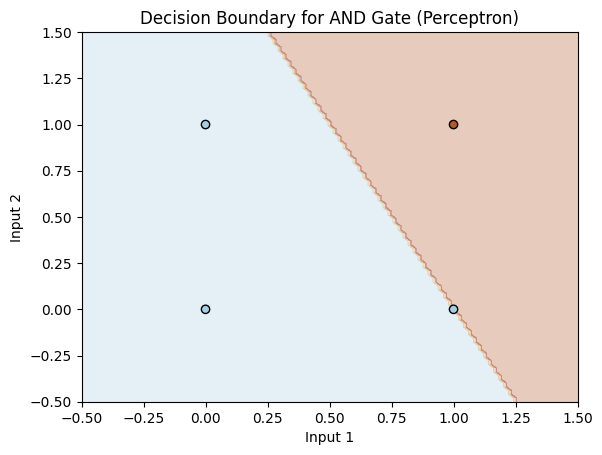

In [18]:
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# compute predictions for grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([predict(point, weights, bias) for point in grid_points])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap=plt.cm.Paired)
plt.title("Decision Boundary for AND Gate (Perceptron)")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()


Questions:

• How do the weights and bias values change during training for the AND gate?

  During training of the AND gate, the weights and bias values get updated or changed as per the following formula:
  weights += learning_rate * error * xi
  bias += learning_rate * error


• Can the perceptron successfully learn the AND logic with a linear decision boundary?

  Yes it can as we can draw a line which clearly separates the three false points from the one true point as per the truth table of the AND gate.

2. OR Gate Classification

• Scenario:

Your next task is to design a perceptron that mimics the behavior of an OR gate. The OR gate outputs 1 if at least one of its inputs is 1.


• Lab Task: Using Google Colab, create a Single Layer Perceptron to classify the output of an OR gate. Perform the following steps:

• Prepare the dataset for the OR gate's truth table.

In [21]:
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
# Outputs
y = np.array([0, 1, 1, 1])

• Define and initialize a Single Layer Perceptron model.

In [23]:
np.random.seed(42)
weights = np.random.rand(2)   # random initialization
bias = np.random.rand(1)      # random bias
lr = 0.1                      # learning rate
epochs = 10                   # number of iterations

def step_function(x):
    return np.where(x >= 0, 1, 0)


• Implement the training process and adjust the perceptron's weights.

In [24]:
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}")
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_pred = step_function(linear_output)
        error = y[i] - y_pred

        # Update rule (Perceptron learning)
        weights += lr * error * X[i]
        bias += lr * error

        print(f"Input: {X[i]}, Target: {y[i]}, Pred: {y_pred}, Error: {error}")
        print(f"Updated weights: {weights}, Updated bias: {bias}")


Epoch 1
Input: [0 0], Target: 0, Pred: [1], Error: [-1]
Updated weights: [0.37454012 0.95071431], Updated bias: [0.63199394]
Input: [0 1], Target: 1, Pred: [1], Error: [0]
Updated weights: [0.37454012 0.95071431], Updated bias: [0.63199394]
Input: [1 0], Target: 1, Pred: [1], Error: [0]
Updated weights: [0.37454012 0.95071431], Updated bias: [0.63199394]
Input: [1 1], Target: 1, Pred: [1], Error: [0]
Updated weights: [0.37454012 0.95071431], Updated bias: [0.63199394]

Epoch 2
Input: [0 0], Target: 0, Pred: [1], Error: [-1]
Updated weights: [0.37454012 0.95071431], Updated bias: [0.53199394]
Input: [0 1], Target: 1, Pred: [1], Error: [0]
Updated weights: [0.37454012 0.95071431], Updated bias: [0.53199394]
Input: [1 0], Target: 1, Pred: [1], Error: [0]
Updated weights: [0.37454012 0.95071431], Updated bias: [0.53199394]
Input: [1 1], Target: 1, Pred: [1], Error: [0]
Updated weights: [0.37454012 0.95071431], Updated bias: [0.53199394]

Epoch 3
Input: [0 0], Target: 0, Pred: [1], Error: 

• Validate the perceptron's performance with the OR gate input combinations.

In [25]:
print("\nFinal Results:")
for i in range(len(X)):
    linear_output = np.dot(X[i], weights) + bias
    y_pred = step_function(linear_output)
    print(f"Input: {X[i]} -> Predicted: {y_pred}, Target: {y[i]}")



Final Results:
Input: [0 0] -> Predicted: [0], Target: 0
Input: [0 1] -> Predicted: [1], Target: 1
Input: [1 0] -> Predicted: [1], Target: 1
Input: [1 1] -> Predicted: [1], Target: 1


Questions:

• What changes in the perceptron's weights are necessary to represent the OR gate logic?

• How does the linear decision boundary look for the OR gate classification?

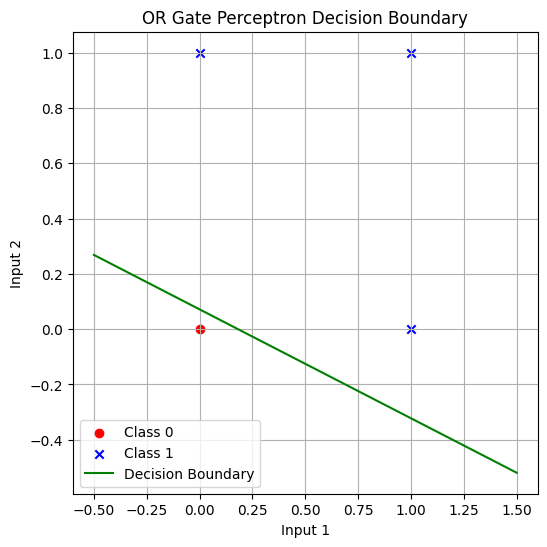

In [26]:
plt.figure(figsize=(6,6))

# Plot data points
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='red', marker='o', label="Class 0" if i==0 else "")
    else:
        plt.scatter(X[i][0], X[i][1], color='blue', marker='x', label="Class 1" if i==1 else "")

# Plot decision boundary: w1*x1 + w2*x2 + b = 0  ->  x2 = -(w1/w2)*x1 - b/w2
x_values = np.linspace(-0.5, 1.5, 100)
if weights[1] != 0:  # avoid division by zero
    y_values = -(weights[0]/weights[1]) * x_values - (bias/weights[1])
    plt.plot(x_values, y_values, label="Decision Boundary", color='green')

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("OR Gate Perceptron Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()


Questions:

• What changes in the perceptron's weights are necessary to represent the OR gate logic?
  The perceptrons weights remain positive in order to represent the OR gate logic whereas the bias gets adjusted to be negative.

• How does the linear decision boundary look for the OR gate classification?
  The boundary line has three true points above it and one false point below it and it has a negative slope.


3. AND-NOT Gate Classification

• Scenario:
You need to implement an AND-NOT gate, which outputs 1 only if the first input is 1 and the second input is 0.

• Lab Task: Design a Single Layer Perceptron in Google Colab to classify the output of an AND-NOT gate. Follow these steps:

• Create the truth table for the AND-NOT gate.

In [27]:
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([0, 0, 1, 0])  # AND-NOT truth table

• Define a perceptron model with an appropriate activation function.

In [28]:
np.random.seed(42)
weights = np.random.rand(2)   # random weights
bias = np.random.rand(1)      # random bias
lr = 0.1                      # learning rate
epochs = 15                   # number of iterations

def step_function(x):
    return np.where(x >= 0, 1, 0)


• Train the model on the AND-NOT gate dataset.

In [32]:
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}")
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_pred = step_function(linear_output)
        error = y[i] - y_pred

        # Perceptron update rule
        weights += lr * error * X[i]
        bias += lr * error

    # Print weights and bias after each epoch
    print(f"After epoch {epoch+1}: weights = {weights}, bias = {bias}")



Epoch 1
After epoch 1: weights = [ 0.17454012 -0.04928569], bias = [-0.16800606]

Epoch 2
After epoch 2: weights = [ 0.17454012 -0.04928569], bias = [-0.16800606]

Epoch 3
After epoch 3: weights = [ 0.17454012 -0.04928569], bias = [-0.16800606]

Epoch 4
After epoch 4: weights = [ 0.17454012 -0.04928569], bias = [-0.16800606]

Epoch 5
After epoch 5: weights = [ 0.17454012 -0.04928569], bias = [-0.16800606]

Epoch 6
After epoch 6: weights = [ 0.17454012 -0.04928569], bias = [-0.16800606]

Epoch 7
After epoch 7: weights = [ 0.17454012 -0.04928569], bias = [-0.16800606]

Epoch 8
After epoch 8: weights = [ 0.17454012 -0.04928569], bias = [-0.16800606]

Epoch 9
After epoch 9: weights = [ 0.17454012 -0.04928569], bias = [-0.16800606]

Epoch 10
After epoch 10: weights = [ 0.17454012 -0.04928569], bias = [-0.16800606]

Epoch 11
After epoch 11: weights = [ 0.17454012 -0.04928569], bias = [-0.16800606]

Epoch 12
After epoch 12: weights = [ 0.17454012 -0.04928569], bias = [-0.16800606]

Epoch 13


• Test the model and analyze its classification accuracy.

In [30]:
print("\nFinal Results:")
for i in range(len(X)):
    linear_output = np.dot(X[i], weights) + bias
    y_pred = step_function(linear_output)
    print(f"Input: {X[i]} -> Predicted: {y_pred}, Target: {y[i]}")




Final Results:
Input: [0 0] -> Predicted: [0], Target: 0
Input: [0 1] -> Predicted: [0], Target: 0
Input: [1 0] -> Predicted: [1], Target: 1
Input: [1 1] -> Predicted: [0], Target: 0


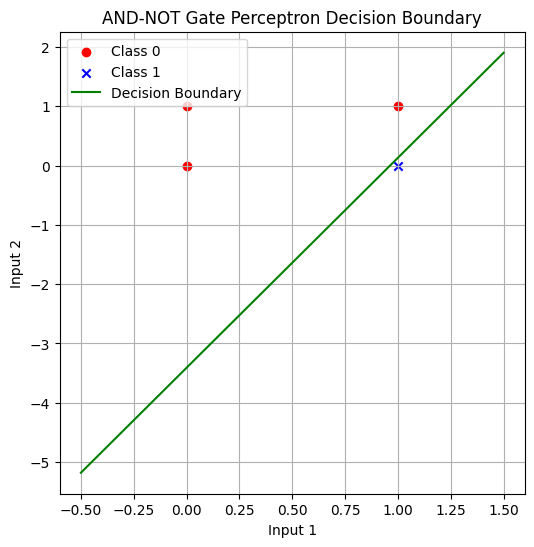

In [31]:
plt.figure(figsize=(6,6))

# Plot data points
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='red', marker='o', label="Class 0" if i==0 else "")
    else:
        plt.scatter(X[i][0], X[i][1], color='blue', marker='x', label="Class 1" if i==2 else "")

# Plot decision boundary: w1*x1 + w2*x2 + b = 0  ->  x2 = -(w1/w2)*x1 - b/w2
x_values = np.linspace(-0.5, 1.5, 100)
if weights[1] != 0:  # avoid division by zero
    y_values = -(weights[0]/weights[1]) * x_values - (bias/weights[1])
    plt.plot(x_values, y_values, label="Decision Boundary", color='green')

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("AND-NOT Gate Perceptron Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()


Questions:

• What is the perceptron's weight configuration after training for the AND-NOT gate?

  We see that the weight for Input1 is positive while the weight for Input2 is negative

• How does the perceptron handle cases where both inputs are 1 or 0?

  It detects them as false (0)

4. XOR Gate Classification

• Scenario:
The XOR gate is known for its complexity, as it outputs 1 only when the inputs are different. This is a challenge for a Single Layer Perceptron since XOR is not linearly separable.

• Lab Task: Attempt to implement a Single Layer Perceptron in Google Colab to classify the output of an XOR gate. Perform the following steps:

• Create the XOR gate's truth table dataset.

In [33]:
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([0, 1, 1, 0])  # XOR truth table

• Implement the perceptron model and train it using the XOR dataset.

In [35]:
np.random.seed(42)
weights = np.random.rand(2)   # random weights
bias = np.random.rand(1)      # random bias
lr = 0.1                      # learning rate
epochs = 15                   # number of iterations

def step_function(x):
    return np.where(x >= 0, 1, 0)

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}")
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_pred = step_function(linear_output)
        error = y[i] - y_pred

        # Perceptron update rule
        weights += lr * error * X[i]
        bias += lr * error

    # Print weights and bias after each epoch
    print(f"After epoch {epoch+1}: weights = {weights}, bias = {bias}")



Epoch 1
After epoch 1: weights = [0.27454012 0.85071431], bias = [0.53199394]

Epoch 2
After epoch 2: weights = [0.17454012 0.75071431], bias = [0.33199394]

Epoch 3
After epoch 3: weights = [0.07454012 0.65071431], bias = [0.13199394]

Epoch 4
After epoch 4: weights = [-0.02545988  0.55071431], bias = [-0.06800606]

Epoch 5
After epoch 5: weights = [-0.02545988  0.45071431], bias = [-0.06800606]

Epoch 6
After epoch 6: weights = [-0.02545988  0.35071431], bias = [-0.06800606]

Epoch 7
After epoch 7: weights = [-0.02545988  0.25071431], bias = [-0.06800606]

Epoch 8
After epoch 8: weights = [-0.02545988  0.15071431], bias = [-0.06800606]

Epoch 9
After epoch 9: weights = [-0.02545988  0.05071431], bias = [-0.06800606]

Epoch 10
After epoch 10: weights = [-0.12545988  0.05071431], bias = [-0.06800606]

Epoch 11
After epoch 11: weights = [-0.12545988  0.05071431], bias = [0.03199394]

Epoch 12
After epoch 12: weights = [-0.12545988  0.05071431], bias = [0.03199394]

Epoch 13
After epoch

• Observe and discuss the perceptron's performance in this scenario.

In [36]:
print("\nFinal Results:")
for i in range(len(X)):
    linear_output = np.dot(X[i], weights) + bias
    y_pred = step_function(linear_output)
    print(f"Input: {X[i]} -> Predicted: {y_pred}, Target: {y[i]}")



Final Results:
Input: [0 0] -> Predicted: [1], Target: 0
Input: [0 1] -> Predicted: [1], Target: 1
Input: [1 0] -> Predicted: [0], Target: 1
Input: [1 1] -> Predicted: [0], Target: 0


We see that the perceptron cannot correctly classify all XOR inputs because XOR is not linearly separable.

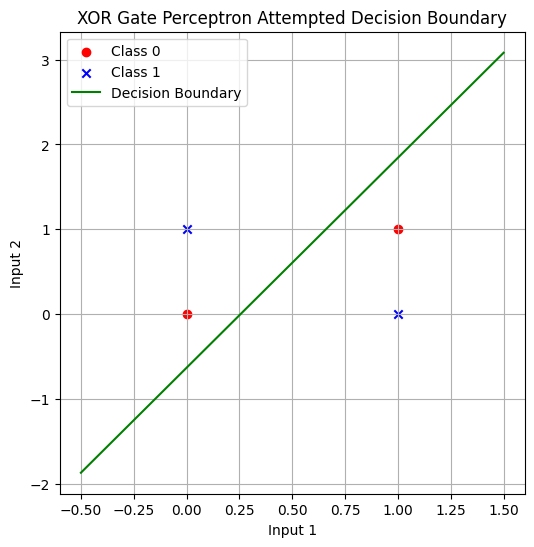

In [37]:
plt.figure(figsize=(6,6))

# Plot data points
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='red', marker='o', label="Class 0" if i==0 else "")
    else:
        plt.scatter(X[i][0], X[i][1], color='blue', marker='x', label="Class 1" if i==1 else "")

# Plot decision boundary: w1*x1 + w2*x2 + b = 0 -> x2 = -(w1/w2)*x1 - b/w2
x_values = np.linspace(-0.5, 1.5, 100)
if weights[1] != 0:
    y_values = -(weights[0]/weights[1]) * x_values - (bias/weights[1])
    plt.plot(x_values, y_values, label="Decision Boundary", color='green')

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("XOR Gate Perceptron Attempted Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()


Questions:

• Why does the Single Layer Perceptron struggle to classify the XOR gate?

  The SLP struggles to correctly classify the XOR gate as we cannot draw a straight line which clearly separates the true and false outputs, hence it is a non linear problem. By observing the weight and bias values while training we see that the perceptron will oscillate its weights and bias during training but will never converge to a solution that correctly classifies all inputs.

• What modifications can be made to the neural network model to handle the XOR gate correctly?

  We can modify the Single Layer Perceptron to a Multi Layer Percentron